# MTCars Exploratory Analysis

Descriptive analysis of fuel economy and vehicle characteristics. Conclusions are intentionally non-causal.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_dir = Path.cwd()
if project_dir.name == 'notebooks':
    project_dir = project_dir.parent
data_path = project_dir / 'data' / 'mtcars.csv'
images_dir = project_dir / 'images'
images_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path).rename(columns={'rownames':'Model'})
df['Transmission'] = df['am'].map({0:'Automatic', 1:'Manual'})
print(f'Rows: {len(df)}, columns: {df.shape[1]}')
df.head()

Rows: 32, columns: 13


,Model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,Transmission
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,Manual
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,Manual
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,Manual
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,Automatic
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,Automatic


## Transmission comparison

In [2]:
transmission_summary = df.groupby('Transmission').agg(
    Vehicles=('mpg','size'), Average_MPG=('mpg','mean'), Median_MPG=('mpg','median'), Average_Weight_1000lb=('wt','mean'))
transmission_summary['Average_Weight_lb'] = transmission_summary['Average_Weight_1000lb'] * 1000
transmission_summary.round(2)

,Vehicles,Average_MPG,Median_MPG,Average_Weight_1000lb,Average_Weight_lb
Transmission,,,,,
Automatic,19,17.15,17.3,3.77,3768.89
Manual,13,24.39,22.8,2.41,2411.00


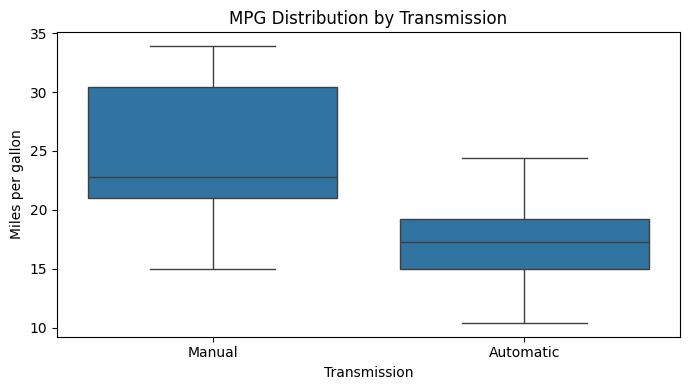

In [3]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Transmission', y='mpg')
plt.title('MPG Distribution by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Miles per gallon')
plt.tight_layout()
plt.savefig(images_dir / 'mpg_by_transmission.png', dpi=160, bbox_inches='tight')
plt.show()

The manual group has higher average and median MPG in this sample, but transmission is associated with other design differences such as weight, cylinders, and horsepower. This comparison does not isolate a causal transmission effect.

## Weight and fuel economy

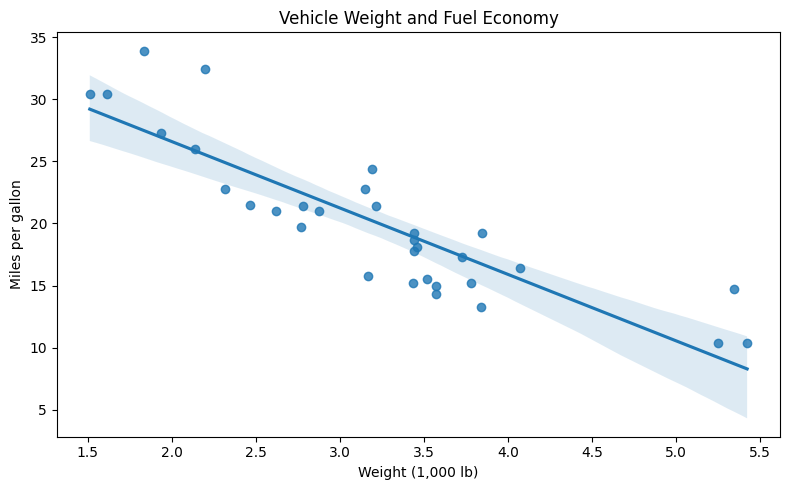

Correlation between weight and MPG: -0.868


In [4]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='wt', y='mpg')
plt.title('Vehicle Weight and Fuel Economy')
plt.xlabel('Weight (1,000 lb)')
plt.ylabel('Miles per gallon')
plt.tight_layout()
plt.savefig(images_dir / 'weight_vs_mpg.png', dpi=160, bbox_inches='tight')
plt.show()

weight_corr = df['wt'].corr(df['mpg'])
print(f'Correlation between weight and MPG: {weight_corr:.3f}')

Weight has a strong negative association with MPG in this sample. The relationship is descriptive and may be influenced by engine size, cylinders, vehicle purpose, and other design variables.

## MPG by cylinder count

,count,mean,median,min,max
cyl,,,,,
4,11,26.66,26.0,21.4,33.9
6,7,19.74,19.7,17.8,21.4
8,14,15.10,15.2,10.4,19.2


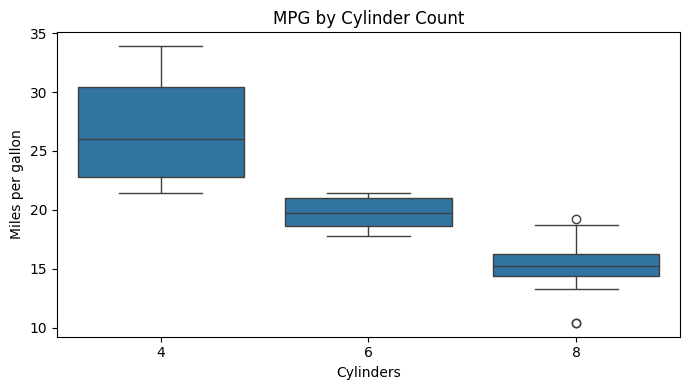

In [5]:
cylinder_summary = df.groupby('cyl')['mpg'].agg(['count','mean','median','min','max']).round(2)
display(cylinder_summary)
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='cyl', y='mpg')
plt.title('MPG by Cylinder Count')
plt.xlabel('Cylinders')
plt.ylabel('Miles per gallon')
plt.tight_layout()
plt.savefig(images_dir / 'mpg_by_cylinders.png', dpi=160, bbox_inches='tight')
plt.show()

Four-cylinder vehicles have higher MPG in this dataset, but cylinder count is related to weight, displacement, horsepower, and intended vehicle use. The result should not be interpreted as causal proof.

## Correlation review

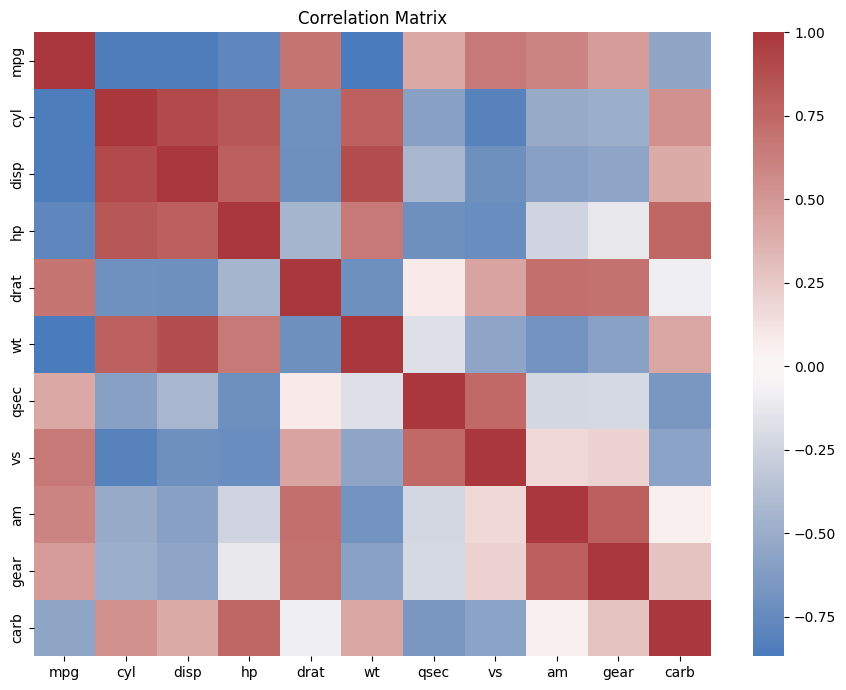

In [6]:
numeric = df.drop(columns=['Model','Transmission']).corr()
plt.figure(figsize=(9,7))
sns.heatmap(numeric, cmap='vlag', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(images_dir / 'correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

## Reference vehicles

In [7]:
reference = df.loc[df['Model'].isin(['Toyota Corolla','Lincoln Continental']), ['Model','mpg','cyl','hp','wt','Transmission']].copy()
reference['Weight_lb'] = reference['wt'] * 1000
reference[['Model','mpg','cyl','hp','Weight_lb','Transmission']]

,Model,mpg,cyl,hp,Weight_lb,Transmission
15,Lincoln Continental,10.4,8,215,5424.0,Automatic
19,Toyota Corolla,33.9,4,65,1835.0,Manual


## Conclusion

Within this small sample, lower weight, fewer cylinders, and smaller displacement are associated with higher MPG. Manual-transmission vehicles also show higher MPG, but the groups differ on several vehicle characteristics. The analysis is useful for descriptive exploration and hypothesis generation, not for proving mechanical or causal relationships.